# Q2.1 — Predicting 2014 Resale Flat Prices

Predict a resale flat's transaction price using **flat type, flat age, and town**.

Approach:
1. Filter to 2011–2014 transactions (recent window feeding into the 2014 prediction task). Join to geo_addresses_with_poi_2014
2. Light EDA — nulls, distributions, price trend.
3. Rescale historical prices to a **2013 Q4** basis using the RPI table (`utils.readjust_price`), so the
   model isn't confounded by market-wide price growth over 2011–2014. We deliberately rebase to the
   quarter immediately *before* the prediction year (not to a 2014 quarter) so no future RPI information
   leaks into the training target.
4. Build a reusable preprocessing + model pipeline (one-hot encode `town`/`flat_type`, scale numeric
   features where the model needs it).
5. Train/compare 4 models: Linear Regression, Random Forest, XGBoost, SVR.
6. Evaluate with RMSE, MAE and MAPE, pick a best model.
7. Predict across each quarter of 2014 and check for error drift over the year.
8. Walk-forward validation: retrain on data up to Q(n), predict Q(n+1), for each quarter of 2014 —
   rescaling prices to the latest completed training quarter each time before predicting the next
   quarter (so the rebasing point always moves forward with the training cutoff, never ahead of it).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent / "data"
SRC_DIR = curr_dir.parent
sys.path.append(str(SRC_DIR))

from utils import readjust_price, get_storey_mid

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor


## 1. Load data and filter to 2011–2014

In [3]:
master_df = pd.read_csv(DATA_DIR / "merged_resale_prices.csv", parse_dates=["month"])
rpi = pd.read_csv(DATA_DIR / "rpi-table.csv")
geo_addresses_with_poi_2014 = pd.read_csv(DATA_DIR / 'geo_addresses_with_poi_2014.csv')

df = master_df[(master_df["month"].dt.year >= 2011) & (master_df["month"].dt.year <= 2014)].copy().reset_index(drop=True)
df["quarter"] = df["month"].dt.to_period("Q")

print(f"Rows 2011-2014: {len(df):,}")
print(f"Date range: {df['month'].min().date()} to {df['month'].max().date()}")
df.head()


Rows 2011-2014: 77,672
Date range: 2011-01-01 to 2014-12-01


,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,quarter
0,2011-01-01,ANG MO KIO,3 ROOM,208,ANG MO KIO AVE 1,208 ANG MO KIO AVE 1,07 TO 09,73.0,New Generation,1976,35,64,333000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1
1,2011-01-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,216 ANG MO KIO AVE 1,07 TO 09,73.0,New Generation,1976,35,64,328000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1
2,2011-01-01,ANG MO KIO,3 ROOM,219,ANG MO KIO AVE 1,219 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1977,34,65,320000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1
3,2011-01-01,ANG MO KIO,3 ROOM,220,ANG MO KIO AVE 1,220 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1977,34,65,308000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1
4,2011-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1978,33,66,285000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1


In [4]:
df = df.merge(geo_addresses_with_poi_2014[["address", "dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"]], how="left", on="address")

## 2. Light EDA

In [5]:
# Null check
print("Null counts:")
print(df.isnull().sum())
df.dropna(inplace=True)

print("\nRow count by quarter:")
print(df["quarter"].value_counts().sort_index())

print("\nflat_type value counts:")
print(df["flat_type"].value_counts())

print("\ntown value counts:")
print(df["town"].value_counts())


Null counts:
month                      0
town                       0
flat_type                  0
block                      0
street_name                0
address                    0
storey_range               0
floor_area_sqm             0
flat_model                 0
lease_commence_date        0
flat_age_years             0
remaining_lease_years      0
resale_price               0
source_file                0
quarter                    0
dist_to_MRT              162
dist_to_Mall             162
dist_to_school           162
dist_to_pop_school       162
dtype: int64

Row count by quarter:
quarter
2011Q1    5841
2011Q2    5928
2011Q3    5505
2011Q4    4920
2012Q1    5531
2012Q2    6459
2012Q3    6008
2012Q4    5161
2013Q1    3817
2013Q2    4607
2013Q3    4045
2013Q4    3604
2014Q1    3496
2014Q2    4220
2014Q3    4153
2014Q4    4215
Freq: Q-DEC, Name: count, dtype: int64

flat_type value counts:
flat_type
4 ROOM              29561
3 ROOM              22528
5 ROOM              18237


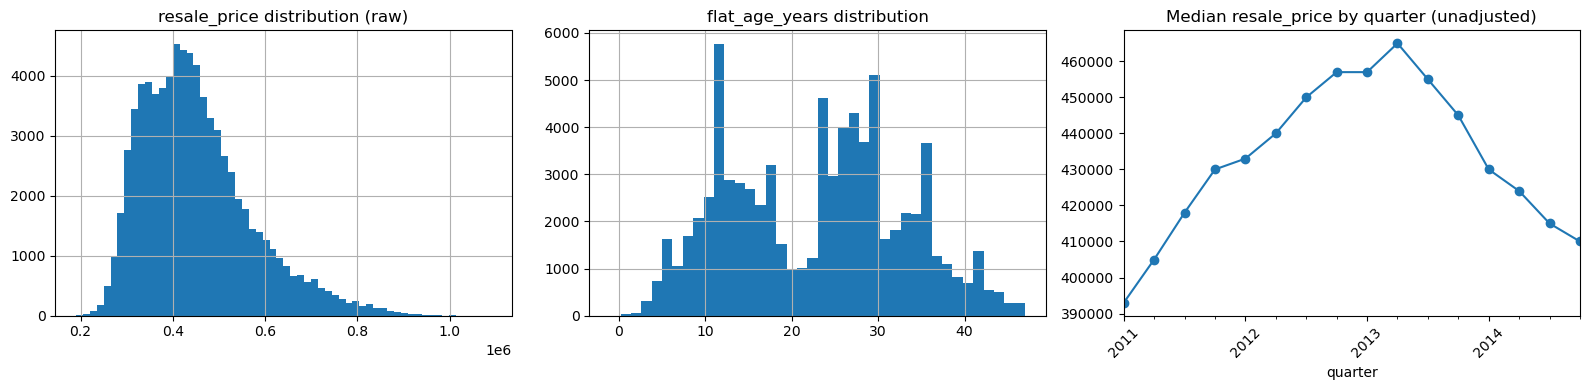

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["resale_price"].hist(bins=60, ax=axes[0])
axes[0].set_title("resale_price distribution (raw)")

df["flat_age_years"].hist(bins=40, ax=axes[1])
axes[1].set_title("flat_age_years distribution")

df.groupby("quarter")["resale_price"].median().plot(ax=axes[2], marker="o")
axes[2].set_title("Median resale_price by quarter (unadjusted)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 2.1 Why tree-based models: non-linearity and interaction checks

Linear Regression assumes each feature contributes an additive, constant-slope effect on price. The
plots below check whether that assumption holds for `mid_storey`, `floor_area_sqm`, `flat_age_years`,
and their interactions with `town`/`flat_type`. We compute `mid_storey` and rescaled price here
(pulling forward the values defined later in the notebook) purely for this diagnostic — non-linearity
in the raw relationship is what matters, not the exact price basis.

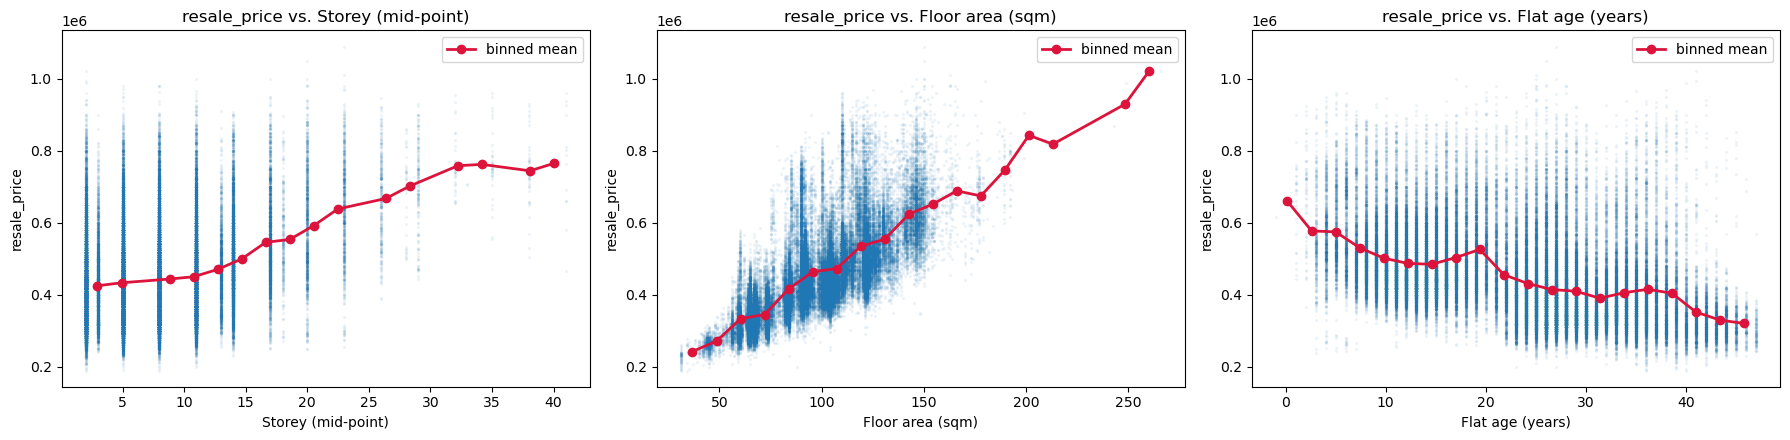

In [7]:
from utils import get_storey_mid

eda = df.copy()
eda["mid_storey"] = eda["storey_range"].apply(get_storey_mid)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, col, title in [
    (axes[0], "mid_storey", "Storey (mid-point)"),
    (axes[1], "floor_area_sqm", "Floor area (sqm)"),
    (axes[2], "flat_age_years", "Flat age (years)"),
]:
    ax.scatter(eda[col], eda["resale_price"], s=2, alpha=0.05)
    binned_mean = eda.groupby(pd.cut(eda[col], bins=20))["resale_price"].mean()
    bin_mid = binned_mean.index.map(lambda iv: iv.mid).astype(float)
    ax.plot(bin_mid, binned_mean.values, color="crimson", marker="o", linewidth=2, label="binned mean")
    ax.set_xlabel(title)
    ax.set_ylabel("resale_price")
    ax.set_title(f"resale_price vs. {title}")
    ax.legend()

plt.tight_layout()
plt.show()


**Reading the plots above:** if the relationship were linear, the red binned-mean line would be
roughly straight. In practice `mid_storey` and `flat_age_years` both show visible curvature (e.g.
diminishing/accelerating price change at the extremes), which a plain linear term can't fit without
manually adding polynomial features — trees split on thresholds and pick this up automatically.

**Interaction check:** does the age–price relationship have the same slope in every town / for every
flat type? If not, Linear Regression (without explicit interaction terms) is mis-specified, since it
forces one global slope per feature.

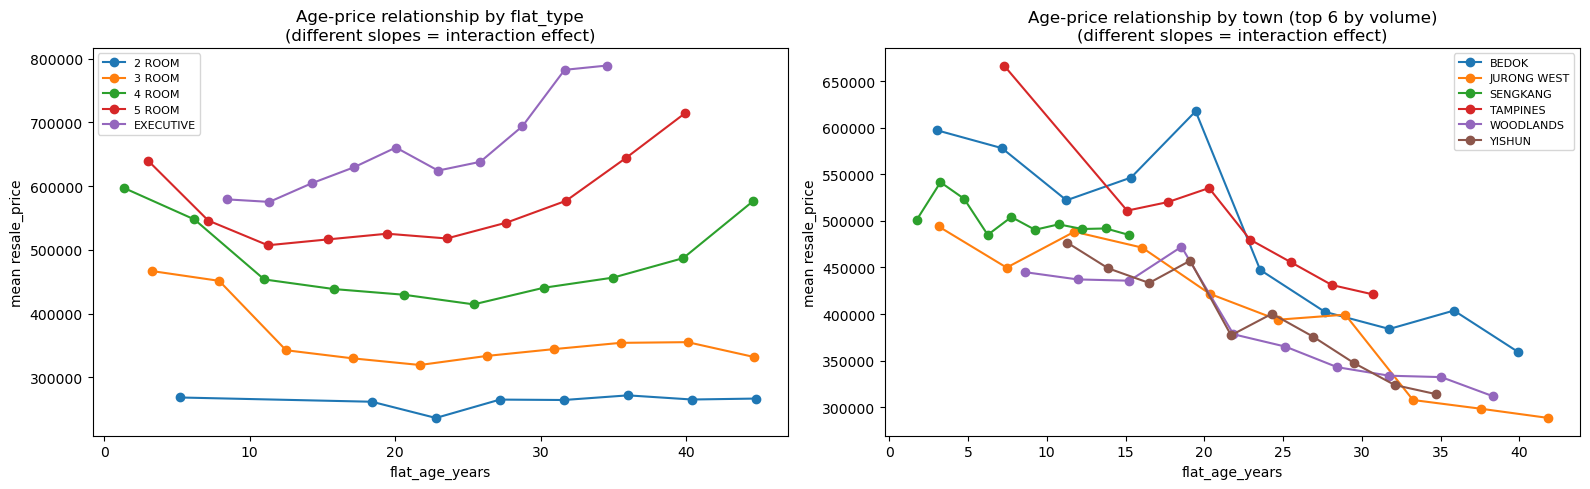

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Age-price slope by flat_type
for ft, group in eda.groupby("flat_type"):
    if len(group) < 200:
        continue
    binned = group.groupby(pd.cut(group["flat_age_years"], bins=10))["resale_price"].mean()
    bin_mid = binned.index.map(lambda iv: iv.mid).astype(float)
    axes[0].plot(bin_mid, binned.values, marker="o", label=ft)
axes[0].set_xlabel("flat_age_years")
axes[0].set_ylabel("mean resale_price")
axes[0].set_title("Age-price relationship by flat_type\n(different slopes = interaction effect)")
axes[0].legend(fontsize=8)

# Age-price slope by town (subset of largest towns for readability)
top_towns = eda["town"].value_counts().head(6).index
for town, group in eda[eda["town"].isin(top_towns)].groupby("town"):
    binned = group.groupby(pd.cut(group["flat_age_years"], bins=10))["resale_price"].mean()
    bin_mid = binned.index.map(lambda iv: iv.mid).astype(float)
    axes[1].plot(bin_mid, binned.values, marker="o", label=town)
axes[1].set_xlabel("flat_age_years")
axes[1].set_ylabel("mean resale_price")
axes[1].set_title("Age-price relationship by town (top 6 by volume)\n(different slopes = interaction effect)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


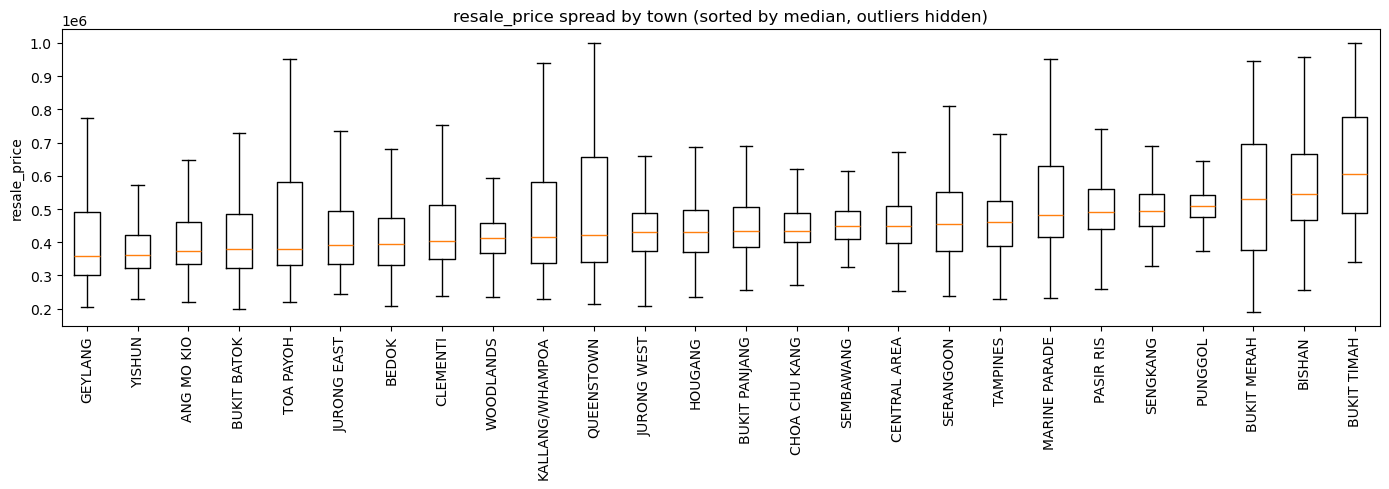

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
town_order = eda.groupby("town")["resale_price"].median().sort_values().index
data_by_town = [eda.loc[eda["town"] == t, "resale_price"].values for t in town_order]
ax.boxplot(data_by_town, tick_labels=town_order, showfliers=False)
ax.set_xticklabels(town_order, rotation=90)
ax.set_title("resale_price spread by town (sorted by median, outliers hidden)")
ax.set_ylabel("resale_price")
plt.tight_layout()
plt.show()


**Takeaway:** `mid_storey` and `flat_age_years` show non-linear (curved) relationships with price, the
age–price slope differs materially by `flat_type` and `town` (an interaction Linear Regression can't
capture without manually engineered interaction terms), and `town` medians span a wide, unevenly-spaced
range with heavy-tailed within-town distributions. Tree-based models (Random Forest, XGBoost) split on
thresholds per feature and per branch, so they capture curvature and interactions natively — consistent
with the large RMSE/MAE gap in favor of Random Forest/XGBoost over Linear Regression seen in section 6.

## 3. Rescale prices to 2013 Q4 basis

Using `utils.readjust_price`, rebase every transaction's price to the RPI level at **2013 Q4** — the
last completed quarter before the 2014 prediction target. This removes market-wide price trend from
the target variable without leaking any 2014 information into training.

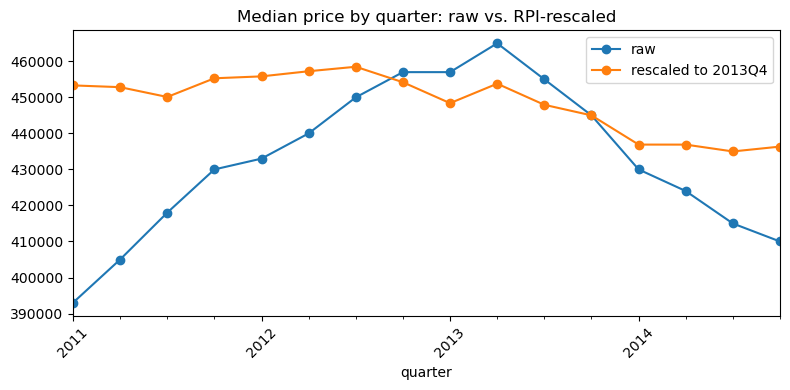

,month,quarter,resale_price,Rescale_price_2013_Q4
0,2011-01-01,2011Q1,333000.0,384109.177215
1,2011-01-01,2011Q1,328000.0,378341.772152
2,2011-01-01,2011Q1,320000.0,369113.924051
3,2011-01-01,2011Q1,308000.0,355272.151899
4,2011-01-01,2011Q1,285000.0,328742.088608


In [10]:
BASIS_YEAR, BASIS_QUARTER = 2013, 4
rescale_col = f"Rescale_price_{BASIS_YEAR}_Q{BASIS_QUARTER}"

df = readjust_price(df, rpi, target_year=BASIS_YEAR, target_quarter=BASIS_QUARTER)

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby("quarter")["resale_price"].median().plot(ax=ax, marker="o", label="raw")
df.groupby("quarter")[rescale_col].median().plot(ax=ax, marker="o", label=f"rescaled to {BASIS_YEAR}Q{BASIS_QUARTER}")
ax.set_title("Median price by quarter: raw vs. RPI-rescaled")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

df[["month", "quarter", "resale_price", rescale_col]].head()


## Feature Engineering

In [11]:
df["mid_storey"] = df['storey_range'].apply(get_storey_mid)

In [12]:
df

,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,quarter,dist_to_MRT,dist_to_Mall,dist_to_school,dist_to_pop_school,Rescale_price_2013_Q4,mid_storey
0,2011-01-01,ANG MO KIO,3 ROOM,208,ANG MO KIO AVE 1,208 ANG MO KIO AVE 1,07 TO 09,73.0,New Generation,1976,35,64,333000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1,871.470025,766.058448,549.154374,1205.405437,384109.177215,8.0
1,2011-01-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,216 ANG MO KIO AVE 1,07 TO 09,73.0,New Generation,1976,35,64,328000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1,716.006325,804.709119,403.611139,1129.981714,378341.772152,8.0
2,2011-01-01,ANG MO KIO,3 ROOM,219,ANG MO KIO AVE 1,219 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1977,34,65,320000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1,668.896335,883.702313,386.451518,1038.294145,369113.924051,8.0
3,2011-01-01,ANG MO KIO,3 ROOM,220,ANG MO KIO AVE 1,220 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1977,34,65,308000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1,694.148085,926.335403,424.488420,1001.330795,355272.151899,8.0
4,2011-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1978,33,66,285000.0,"Resale Flat Prices (Based on Approval Date), 2...",2011Q1,389.177329,1002.765762,269.253824,945.184788,328742.088608,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77667,2014-12-01,YISHUN,4 ROOM,821,YISHUN ST 81,821 YISHUN ST 81,04 TO 06,104.0,Model A,1987,27,72,390000.0,Resale Flat Prices (Based on Registration Date...,2014Q4,403.426514,950.859651,621.220487,5832.451170,415051.094891,5.0
77668,2014-12-01,YISHUN,4 ROOM,850,YISHUN ST 81,850 YISHUN ST 81,01 TO 03,104.0,Model A,1988,26,73,375000.0,Resale Flat Prices (Based on Registration Date...,2014Q4,373.676563,605.212545,318.762297,6141.560317,399087.591241,2.0
77669,2014-12-01,YISHUN,4 ROOM,868,YISHUN ST 81,868 YISHUN ST 81,04 TO 06,84.0,Simplified,1987,27,72,341500.0,Resale Flat Prices (Based on Registration Date...,2014Q4,596.560001,638.997055,302.143864,5906.576269,363435.766423,5.0
77670,2014-12-01,YISHUN,4 ROOM,868,YISHUN ST 81,868 YISHUN ST 81,01 TO 03,84.0,Simplified,1987,27,72,317000.0,Resale Flat Prices (Based on Registration Date...,2014Q4,596.560001,638.997055,302.143864,5906.576269,337362.043796,2.0


## 4. Reusable preprocessing + model pipeline

Features: `town` (one-hot), `flat_type` (one-hot), `flat_age_years` (numeric). Target: RPI-rescaled
price (`Rescale_price_2013_Q4`).

`build_pipeline(model, scale_numeric)` wraps any regressor in a `ColumnTransformer` + `Pipeline` so the
same encoding logic is reused across all four models — numeric scaling is toggled per-model since
tree-based models (Random Forest, XGBoost) don't need it, while Linear Regression and SVR do.

In [13]:
CATEGORICAL_FEATURES = ["town", "flat_type", "flat_model"]
NUMERIC_FEATURES = ["flat_age_years", "mid_storey", "floor_area_sqm", "dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"]
FEATURE_COLS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COL = rescale_col


def build_pipeline(model, scale_numeric: bool) -> Pipeline:
    numeric_steps = [("scaler", StandardScaler())] if scale_numeric else [("passthrough", "passthrough")]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("num", Pipeline(numeric_steps) if scale_numeric else "passthrough", NUMERIC_FEATURES),
        ]
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


def evaluate(y_true, y_pred) -> dict:
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred)
    }


## 5. Train/test split: train on 2011–2013, test on 2014

This mirrors the task ("predict 2014 resale prices"): train only on data strictly before 2014, then
evaluate on the full 2014 holdout.

In [14]:
train_mask = df["month"].dt.year <= 2013
test_mask = df["month"].dt.year == 2014

X_train, y_train = df.loc[train_mask, FEATURE_COLS], df.loc[train_mask, TARGET_COL]
X_test, y_test = df.loc[test_mask, FEATURE_COLS], df.loc[test_mask, TARGET_COL]

print(f"Train rows (2011-2013): {len(X_train):,}")
print(f"Test rows (2014): {len(X_test):,}")


Train rows (2011-2013): 61,426
Test rows (2014): 16,084


## 6. Train and compare four models

Linear Regression, Random Forest, XGBoost, and SVR — all through the same `build_pipeline` factory.
SVR is trained on a subsample since its training cost scales poorly with ~140k rows.

In [15]:
SVR_SAMPLE_SIZE = 20_000
RANDOM_STATE = 42

model_specs = {
    "LinearRegression": (LinearRegression(), True),
    "RandomForest": (RandomForestRegressor(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1), False),
    "XGBoost": (XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1), False),
    "SVR": (SVR(kernel="rbf", C=10, epsilon=0.01), True),
}

fitted_models = {}
results = []

for name, (model, scale_numeric) in model_specs.items():
    pipe = build_pipeline(model, scale_numeric)

    if name == "SVR":
        X_fit = X_train.sample(n=SVR_SAMPLE_SIZE, random_state=RANDOM_STATE)
        y_fit = y_train.loc[X_fit.index]
    else:
        X_fit, y_fit = X_train, y_train

    pipe.fit(X_fit, y_fit)
    y_pred = pipe.predict(X_test)

    metrics = evaluate(y_test, y_pred)
    metrics["model"] = name
    results.append(metrics)
    fitted_models[name] = pipe

    print(f"{name:16s}  RMSE={metrics['RMSE']:>10,.0f}  MAE={metrics['MAE']:>10,.0f} MAPE={metrics['MAPE']:>7.2%}")

results_df = pd.DataFrame(results).set_index("model")[["RMSE", "MAE", "MAPE"]].sort_values("RMSE")
results_df


LinearRegression  RMSE=    46,695  MAE=    34,617 MAPE=  7.50%
RandomForest      RMSE=    30,331  MAE=    21,997 MAPE=  4.76%
XGBoost           RMSE=    30,622  MAE=    22,455 MAPE=  4.84%
SVR               RMSE=   121,952  MAE=    90,792 MAPE= 19.69%


,RMSE,MAE,MAPE
model,,,
RandomForest,30330.733118,21996.738337,0.047571
XGBoost,30622.118020,22455.079445,0.048415
LinearRegression,46695.483505,34616.524021,0.075005
SVR,121951.939550,90791.634237,0.196932


Best model by MAPE: RandomForest


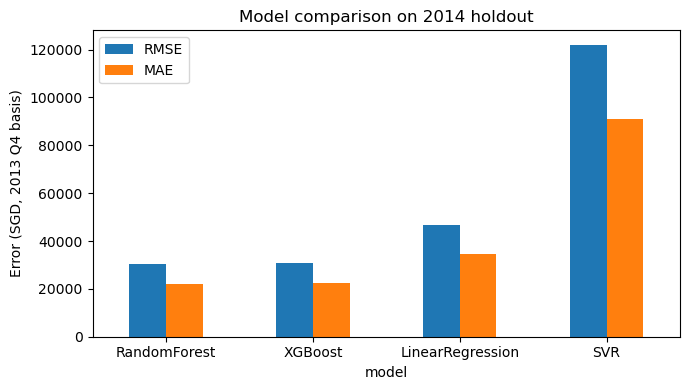

In [18]:
best_model_name = results_df["MAPE"].idxmin()
best_model = fitted_models[best_model_name]
print(f"Best model by MAPE: {best_model_name}")

results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(7, 4), title="Model comparison on 2014 holdout")
plt.ylabel("Error (SGD, 2013 Q4 basis)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Best model by MAPE: RandomForest


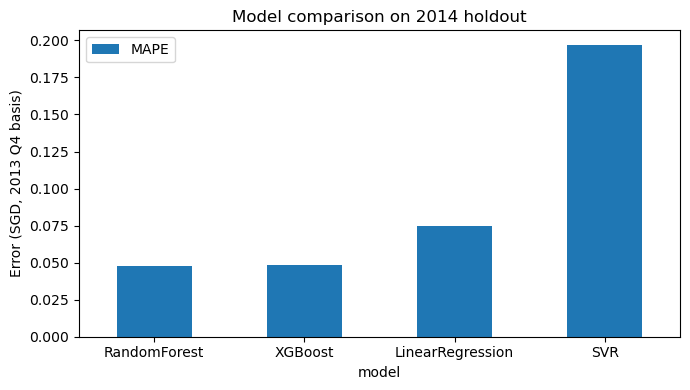

: 

In [ ]:
best_model_name = results_df["MAPE"].idxmin()
best_model = fitted_models[best_model_name]
print(f"Best model by MAPE: {best_model_name}")

results_df[["MAPE"]].plot(kind="bar", figsize=(7, 4), title="Model comparison on 2014 holdout")
plt.ylabel("Error (SGD, 2013 Q4 basis)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 6.1 Feature importance (best static model)

For tree-based models, `.feature_importances_` gives the mean decrease in impurity attributable to
each feature, averaged across all trees. `get_feature_importance_df` pulls the expanded feature names
out of the fitted pipeline's `ColumnTransformer` (one-hot columns for `town`/`flat_type`/`flat_model`,
plus the numeric columns) so importances line up with human-readable names.

In [ ]:
def get_feature_importance_df(fitted_pipeline: Pipeline) -> pd.DataFrame:
    model = fitted_pipeline.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"{type(model).__name__} has no feature_importances_")

    feature_names = fitted_pipeline.named_steps["preprocess"].get_feature_names_out()
    feature_names = [name.split("__", 1)[-1] for name in feature_names]

    return (
        pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


importance_df = get_feature_importance_df(best_model)
top_n = 20

fig, ax = plt.subplots(figsize=(8, 6))
top_importances = importance_df.head(top_n).iloc[::-1]
ax.barh(top_importances["feature"], top_importances["importance"])
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title(f"{best_model_name}: top {top_n} feature importances (static model, trained on 2011-2013)")
plt.tight_layout()
plt.show()

importance_df.head(top_n)


## 7. Error drift across 2014 quarters

Using the model trained once on 2011–2013, check whether prediction error grows as we move further
from the training cutoff (Q1 2014 is "closest", Q4 2014 is "furthest").

In [63]:
df_2014 = df.loc[test_mask].copy()
df_2014["y_pred"] = best_model.predict(df_2014[FEATURE_COLS])

drift_rows = []
for q, group in df_2014.groupby("quarter"):
    metrics = evaluate(group[TARGET_COL], group["y_pred"])
    metrics["quarter"] = str(q)
    metrics["n"] = len(group)
    drift_rows.append(metrics)

drift_df = pd.DataFrame(drift_rows).set_index("quarter")[["n", "RMSE", "MAE", "MAPE"]]
drift_df


,n,RMSE,MAE,MAPE
quarter,,,,
2014Q1,3496,22914.212243,16420.271251,0.035727
2014Q2,4220,27729.680728,20143.366535,0.043412
2014Q3,4153,32526.150203,24172.975647,0.052440
2014Q4,4215,35534.694322,26333.308772,0.056762


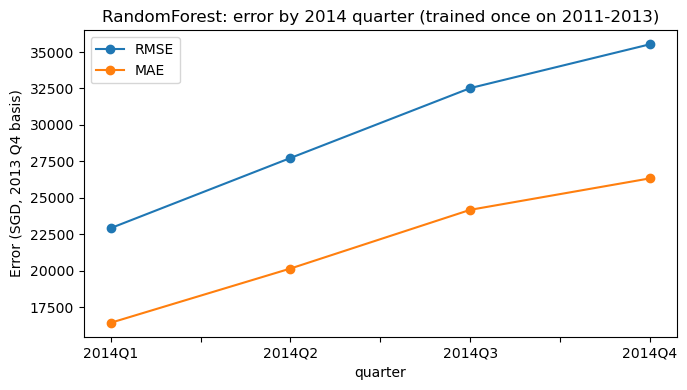

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
drift_df[["RMSE", "MAE"]].plot(marker="o", ax=ax)
ax.set_title(f"{best_model_name}: error by 2014 quarter (trained once on 2011-2013)")
ax.set_ylabel("Error (SGD, 2013 Q4 basis)")
plt.tight_layout()
plt.show()


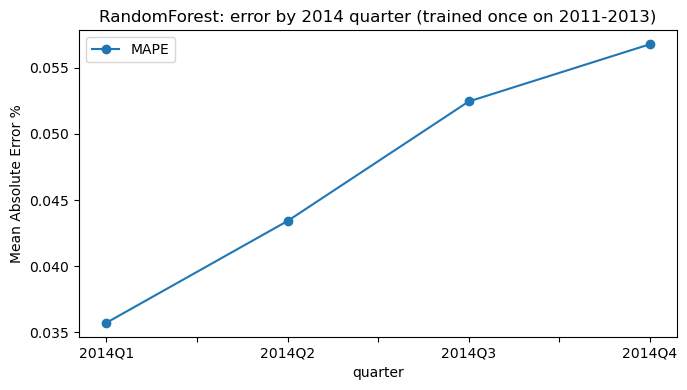

In [65]:
fig, ax = plt.subplots(figsize=(7, 4))
drift_df[["MAPE"]].plot(marker="o", ax=ax)
ax.set_title(f"{best_model_name}: error by 2014 quarter (trained once on 2011-2013)")
ax.set_ylabel("Mean Absolute Error %")
plt.tight_layout()
plt.show()


## 8. Walk-forward validation across 2014 quarters

Retrain the best model on all data up to and including quarter *n*, predict quarter *n+1*, then move
the cutoff forward one quarter and repeat:

- train ≤ 2013 Q4 → predict 2014 Q1
- train ≤ 2014 Q1 → predict 2014 Q2
- train ≤ 2014 Q2 → predict 2014 Q3
- train ≤ 2014 Q3 → predict 2014 Q4

At each step, prices are **re-rescaled to the latest training cutoff quarter** (not fixed at 2013 Q4),
so the rebasing point always tracks the training window and never uses information from the quarter
being predicted.

In [66]:
cutoff_quarters = [pd.Period("2013Q4"), pd.Period("2014Q1"), pd.Period("2014Q2"), pd.Period("2014Q3")]
best_model_ctor, best_scale_numeric = model_specs[best_model_name]

walk_forward_rows = []

for cutoff in cutoff_quarters:
    predict_quarter = cutoff + 1
    cutoff_year, cutoff_q = cutoff.year, cutoff.quarter

    # Rescale ALL raw prices to this cutoff's basis (no future information beyond the cutoff quarter).
    rebased = readjust_price(
        df.drop(columns=[c for c in df.columns if c.startswith("Rescale_price_")]),
        rpi,
        target_year=cutoff_year,
        target_quarter=cutoff_q,
        price_col="resale_price",
    )
    step_target_col = f"Rescale_price_{cutoff_year}_Q{cutoff_q}"

    train_step = rebased[rebased["quarter"] <= cutoff]
    test_step = rebased[rebased["quarter"] == predict_quarter]

    if test_step.empty:
        continue

    model = type(best_model_ctor)(**best_model_ctor.get_params())
    pipe = build_pipeline(model, best_scale_numeric)
    pipe.fit(train_step[FEATURE_COLS], train_step[step_target_col])

    y_pred = pipe.predict(test_step[FEATURE_COLS])
    metrics = evaluate(test_step[step_target_col], y_pred)
    metrics["train_cutoff"] = str(cutoff)
    metrics["predict_quarter"] = str(predict_quarter)
    metrics["n_train"] = len(train_step)
    metrics["n_test"] = len(test_step)
    walk_forward_rows.append(metrics)

    print(
        f"train<= {cutoff}  ->  predict {predict_quarter}  "
        f"(n_train={len(train_step):,}, n_test={len(test_step):,})  "
        f"RMSE={metrics['RMSE']:,.0f}  MAE={metrics['MAE']:,.0f}  MAPE={metrics['MAPE']:>7.2%}"
    )

walk_forward_df = pd.DataFrame(walk_forward_rows).set_index("predict_quarter")[
    ["train_cutoff", "n_train", "n_test", "RMSE", "MAE", "MAPE"]
]
walk_forward_df


train<= 2013Q4  ->  predict 2014Q1  (n_train=61,426, n_test=3,496)  RMSE=22,914  MAE=16,420  MAPE=  3.57%
train<= 2014Q1  ->  predict 2014Q2  (n_train=64,922, n_test=4,220)  RMSE=25,164  MAE=18,389  MAPE=  4.05%
train<= 2014Q2  ->  predict 2014Q3  (n_train=69,142, n_test=4,153)  RMSE=27,776  MAE=20,631  MAPE=  4.64%
train<= 2014Q3  ->  predict 2014Q4  (n_train=73,295, n_test=4,215)  RMSE=29,112  MAE=21,053  MAPE=  4.75%


,train_cutoff,n_train,n_test,RMSE,MAE,MAPE
predict_quarter,,,,,,
2014Q1,2013Q4,61426,3496,22914.212243,16420.271251,0.035727
2014Q2,2014Q1,64922,4220,25164.187690,18389.066767,0.040456
2014Q3,2014Q2,69142,4153,27775.562873,20631.481165,0.046373
2014Q4,2014Q3,73295,4215,29112.055909,21052.684996,0.047504


In [ ]:
walk_forward_rows = []
walk_forward_importances = {}

for cutoff in cutoff_quarters:
    predict_quarter = cutoff + 1
    cutoff_year, cutoff_q = cutoff.year, cutoff.quarter

    # Rescale ALL raw prices to this cutoff's basis (no future information beyond the cutoff quarter).
    rebased = readjust_price(
        df.drop(columns=[c for c in df.columns if c.startswith("Rescale_price_")]),
        rpi,
        target_year=cutoff_year,
        target_quarter=cutoff_q,
        price_col="resale_price",
    )
    step_target_col = f"Rescale_price_{cutoff_year}_Q{cutoff_q}"

    train_step = rebased[rebased["quarter"] <= cutoff]
    test_step = rebased[rebased["quarter"] == predict_quarter]

    if test_step.empty:
        continue

    model = type(best_model_ctor)(**best_model_ctor.get_params())
    pipe = build_pipeline(model, best_scale_numeric)
    pipe.fit(train_step[FEATURE_COLS], train_step[step_target_col])

    y_pred = pipe.predict(test_step[FEATURE_COLS])
    metrics = evaluate(test_step[step_target_col], y_pred)
    metrics["train_cutoff"] = str(cutoff)
    metrics["predict_quarter"] = str(predict_quarter)
    metrics["n_train"] = len(train_step)
    metrics["n_test"] = len(test_step)
    walk_forward_rows.append(metrics)

    if hasattr(model, "feature_importances_"):
        walk_forward_importances[str(predict_quarter)] = get_feature_importance_df(pipe)

    print(
        f"train<= {cutoff}  ->  predict {predict_quarter}  "
        f"(n_train={len(train_step):,}, n_test={len(test_step):,})  "
        f"RMSE={metrics['RMSE']:,.0f}  MAE={metrics['MAE']:,.0f}  MAPE={metrics['MAPE']:>7.2%}"
    )

walk_forward_df = pd.DataFrame(walk_forward_rows).set_index("predict_quarter")[
    ["train_cutoff", "n_train", "n_test", "RMSE", "MAE", "MAPE"]
]
walk_forward_df


In [ ]:
# Wide table: rows = feature, columns = predict_quarter, values = importance
importance_wide = pd.concat(
    {q: imp_df.set_index("feature")["importance"] for q, imp_df in walk_forward_importances.items()},
    axis=1,
)[list(walk_forward_importances.keys())]  # keep quarter order chronological

top_features = importance_wide.mean(axis=1).sort_values(ascending=False).head(10).index

# 1. Line plot: how importance of the top features shifts as the training window rolls forward
fig, ax = plt.subplots(figsize=(9, 5))
for feature in top_features:
    ax.plot(importance_wide.columns, importance_wide.loc[feature], marker="o", label=feature)
ax.set_title(f"{best_model_name}: top-10 feature importance across walk-forward retrains")
ax.set_ylabel("Importance (mean decrease in impurity)")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2. Small multiples: full top-N ranking at each individual retrain
fig, axes = plt.subplots(1, len(walk_forward_importances), figsize=(5 * len(walk_forward_importances), 5), sharex=True)
for ax, (q, imp_df) in zip(axes, walk_forward_importances.items()):
    top = imp_df.head(10).iloc[::-1]
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"predict {q}")
plt.tight_layout()
plt.show()

importance_wide.loc[top_features]


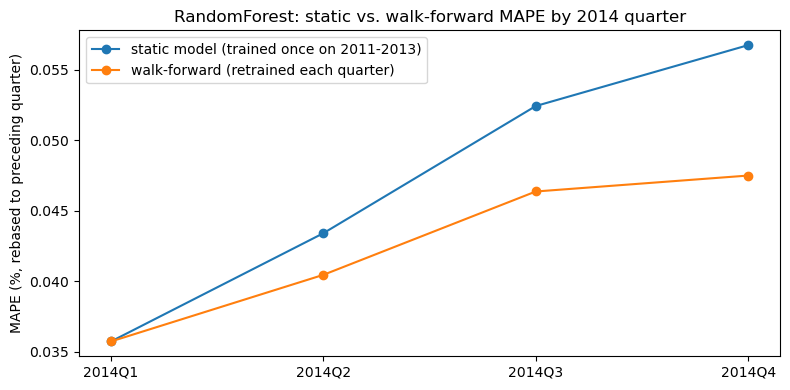

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(drift_df.index.astype(str), drift_df["MAPE"], marker="o", label="static model (trained once on 2011-2013)")
ax.plot(walk_forward_df.index.astype(str), walk_forward_df["MAPE"], marker="o", label="walk-forward (retrained each quarter)")
ax.set_title(f"{best_model_name}: static vs. walk-forward MAPE by 2014 quarter")
ax.set_ylabel("MAPE (%, rebased to preceding quarter)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Summary

- **Model comparison** (`results_df`): RMSE/MAE/MAPE for Linear Regression, Random Forest, XGBoost, and SVR
  on the full 2014 holdout, all trained on 2011–2013 data rescaled to a 2013 Q4 basis.
- **Best model**: Random Forest, selected by lowest MAPE.
- **Error drift** (`drift_df`): whether the statically-trained model's error grows across 2014 quarters
  as the gap to the training cutoff widens.
- **Walk-forward validation** (`walk_forward_df`): retraining each quarter (and re-rebasing prices to
  each new cutoff) shows whether incorporating more recent data closes the gap relative to the static
  model.